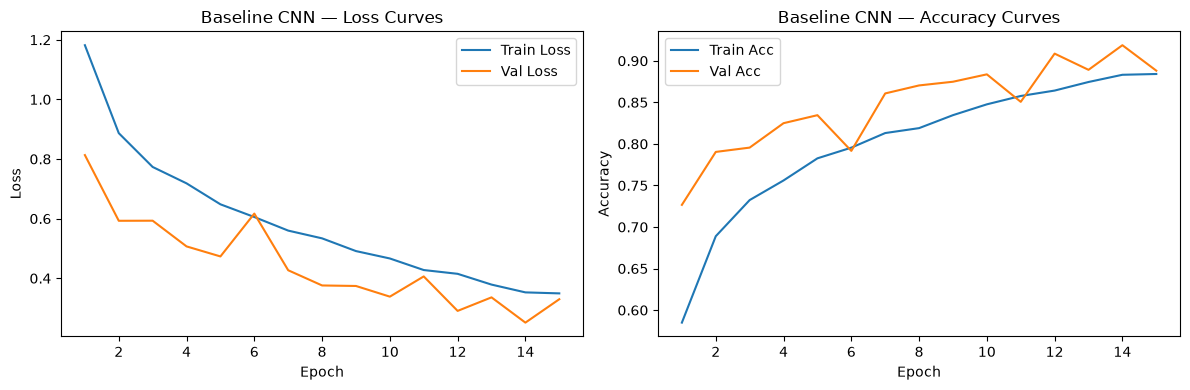

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv("../reports/baseline_training_log.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(log["epoch"], log["train_loss"], label="Train Loss")
axes[0].plot(log["epoch"], log["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Baseline CNN — Loss Curves")
axes[0].legend()

axes[1].plot(log["epoch"], log["train_acc"], label="Train Acc")
axes[1].plot(log["epoch"], log["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Baseline CNN — Accuracy Curves")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/baseline_learning_curves.png", dpi=150)
plt.show()

## Baseline CNN — Results Interpretation

### Overall Performance
The baseline CNN (3 conv blocks, trained from scratch, 15 epochs) achieved 
92.15% test accuracy, macro F1 0.919, weighted F1 0.922. Macro and weighted 
F1 being close indicates performance is fairly even across classes despite 
the mild imbalance identified in Phase 4 — no class is being ignored in 
favor of the larger ones.

### Confirming and Refining the Phase 4 Hypothesis
Phase 4's RGB-similarity analysis flagged AnnualCrop/PermanentCrop as a 
likely confusion pair. The actual confusion matrix confirms PermanentCrop 
as the weakest class (recall 0.81), but shows it's confused almost equally 
with AnnualCrop (31 instances) and HerbaceousVegetation (30 instances) — 
a three-way ambiguity rather than the two-way pair we predicted.

Phase 4 also flagged River/Pasture as numerically similar in RGB space. 
This did NOT materialize as a real confusion pattern. Instead, the actual 
data shows River is primarily confused with Highway (30 + 14 misclassi-
fications combined, bidirectional) — both are long, thin, linear features, 
a structural similarity that mean-RGB analysis cannot capture. This is a 
useful lesson: color-based EDA and shape/texture-based model confusion are 
different phenomena, and the model's real errors revealed a pattern our 
earlier color analysis missed entirely.

### Learning Curves
No clear overfitting signature — train and val loss both trend downward 
through epoch 15 with val loss consistently below train loss (expected, 
since train transforms include augmentation that val/test don't). A mild 
instability around epoch 6 and 11 is visible but self-corrects; likely 
attributable to a fixed learning rate with no scheduler, which we have not 
yet added (planned as a Phase 9 experiment).

### What This Baseline Tells Us
A simple 3-block CNN reaches 92% test accuracy on EuroSAT RGB — a strong 
result that sets a genuinely high bar for transfer learning to clear in 
Phase 8. This also confirms EuroSAT is a relatively "easy" benchmark by 
modern standards (consistent with the original paper's own ~98% reported 
accuracy using deeper architectures), so we should not expect transfer 
learning to produce a dramatic accuracy jump — the more interesting 
comparison will likely be in confusion-pattern improvement (does ResNet18 
resolve the PermanentCrop three-way ambiguity and Highway/River structural 
confusion?) and computational efficiency, not raw accuracy alone.